# Market Sentiment vs Trader Performance Analysis

## Objective
Analyze how market sentiment (Fear & Greed Index) affects trader behavior and profitability.

## Data Sources
- Historical trading dataset
- Fear & Greed Index sentiment dataset

## Key Questions
1. Does sentiment affect trader profitability?
2. Does trading behavior change under fear vs greed?
3. Can sentiment signals inform trading strategy?

In [1]:
# Importing all required libraries
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
from datetime import datetime
# Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load datasets
fear_greed = pd.read_csv("fear_greed_index.csv")
historical_data = pd.read_csv("historical_data.csv")

In [3]:
# Preview Fear & Greed dataset
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
# Preview Historical Trader dataset
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print("Fear & Greed dataset shape:", fear_greed.shape)
print("Historical trader dataset shape:", historical_data.shape)

Fear & Greed dataset shape: (2644, 4)
Historical trader dataset shape: (211224, 16)


In [6]:
# Number of rows and columns
print("Fear & Greed Dataset")
print("Rows:", fear_greed.shape[0])
print("Columns:", fear_greed.shape[1])

print("\nHistorical Trader Dataset")
print("Rows:", historical_data.shape[0])
print("Columns:", historical_data.shape[1])

Fear & Greed Dataset
Rows: 2644
Columns: 4

Historical Trader Dataset
Rows: 211224
Columns: 16


In [7]:
print("Fear & Greed Columns:")
print(fear_greed.columns)

print("\nHistorical Data Columns:")
print(historical_data.columns)

Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Historical Data Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [8]:
print("Missing Values in Fear & Greed Dataset")
print(fear_greed.isnull().sum())

print("\nMissing Values in Historical Trader Dataset")
print(historical_data.isnull().sum())

Missing Values in Fear & Greed Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Historical Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [9]:
print("Duplicate rows in Fear & Greed dataset:", fear_greed.duplicated().sum())
print("Duplicate rows in Historical dataset:", historical_data.duplicated().sum())

Duplicate rows in Fear & Greed dataset: 0
Duplicate rows in Historical dataset: 0


In [10]:
print("Fear & Greed Data Types")
print(fear_greed.dtypes)

print("\nHistorical Data Types")
print(historical_data.dtypes)

Fear & Greed Data Types
timestamp          int64
value              int64
classification    object
date              object
dtype: object

Historical Data Types
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [11]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])
fear_greed.dtypes

timestamp                  int64
value                      int64
classification            object
date              datetime64[ns]
dtype: object

In [12]:
historical_data['Timestamp IST'] = pd.to_datetime(
    historical_data['Timestamp IST'], 
    errors='coerce'
)

In [13]:
historical_data['Timestamp IST'].isnull().sum()

np.int64(131999)

In [14]:
historical_data['Timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [15]:
# convert float timestamp to integer
historical_data['Timestamp'] = historical_data['Timestamp'].astype('int64')

# convert milliseconds timestamp to datetime
historical_data['datetime'] = pd.to_datetime(historical_data['Timestamp'], unit='ms')

In [16]:
historical_data['date'] = historical_data['datetime'].dt.date
historical_data['date'] = pd.to_datetime(historical_data['date'])

In [17]:
historical_data[['Timestamp','datetime','date']].head()

,Timestamp,datetime,date
0,1730000000000,2024-10-27 03:33:20,2024-10-27
1,1730000000000,2024-10-27 03:33:20,2024-10-27
2,1730000000000,2024-10-27 03:33:20,2024-10-27
3,1730000000000,2024-10-27 03:33:20,2024-10-27
4,1730000000000,2024-10-27 03:33:20,2024-10-27


In [18]:
merged_data = historical_data.merge(
    fear_greed[['date','classification']],
    on='date',
    how='left'
)

In [19]:
merged_data[['date','classification']].head()

,date,classification
0,2024-10-27,Greed
1,2024-10-27,Greed
2,2024-10-27,Greed
3,2024-10-27,Greed
4,2024-10-27,Greed


In [20]:
daily_pnl = merged_data.groupby(['date','Account'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [21]:
merged_data['win'] = merged_data['Closed PnL'] > 0

win_rate = merged_data.groupby('Account')['win'].mean().reset_index()

win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [22]:
avg_trade_size = merged_data.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [23]:
trades_per_day = merged_data.groupby('date').size().reset_index(name='num_trades')

trades_per_day.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


In [24]:
long_short_ratio = merged_data['Side'].value_counts(normalize=True)

long_short_ratio

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64

In [25]:
# The dataset does not contain an explicit leverage field. 
# Therefore trade exposure (Size USD) is used as a proxy for risk-taking behavior when comparing trader segments.
merged_data['Size USD'].describe()

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64

In [26]:
summary_metrics = {
    "Total Trades": len(merged_data),
    "Unique Traders": merged_data['Account'].nunique(),
    "Average Trade Size USD": merged_data['Size USD'].mean(),
    "Average PnL": merged_data['Closed PnL'].mean()
}

summary_metrics

{'Total Trades': 211224,
 'Unique Traders': 32,
 'Average Trade Size USD': np.float64(5639.4512103738225),
 'Average PnL': np.float64(48.74900079269401)}

## Part B : Analysis

Performance Comparison: Fear vs Greed

In [27]:
# Average PnL by Sentiment
pnl_by_sentiment = merged_data.groupby('classification')['Closed PnL'].mean().reset_index()
pnl_by_sentiment

,classification,Closed PnL
0,Extreme Greed,25.418772
1,Fear,50.047622
2,Greed,87.894859
3,Neutral,22.229713


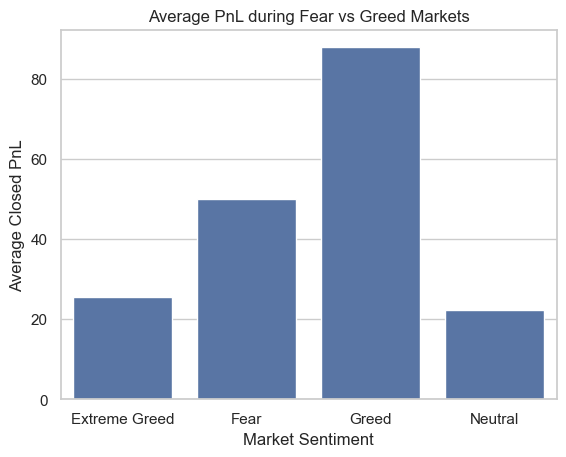

In [28]:
# Visualisation
sns.barplot(data=pnl_by_sentiment, x='classification', y='Closed PnL')
plt.title("Average PnL during Fear vs Greed Markets")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.show()

In [29]:
merged_data['win'] = merged_data['Closed PnL'] > 0
win_rate_sentiment = merged_data.groupby('classification')['win'].mean().reset_index()
win_rate_sentiment

,classification,win
0,Extreme Greed,0.490089
1,Fear,0.415146
2,Greed,0.446471
3,Neutral,0.317182


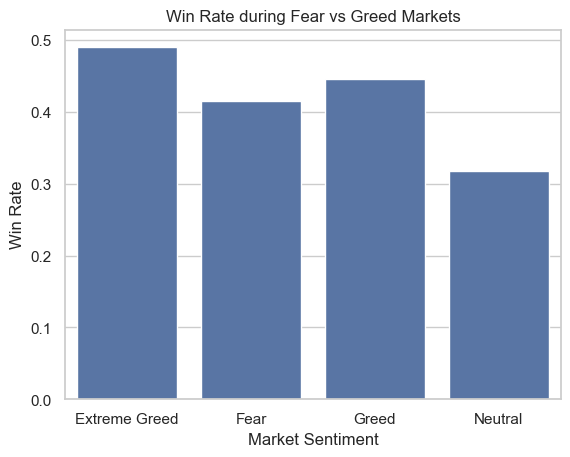

In [30]:
sns.barplot(data=win_rate_sentiment, x='classification', y='win')
plt.title("Win Rate during Fear vs Greed Markets")
plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")
plt.show()

In [31]:
loss_trades = merged_data[merged_data['Closed PnL'] < 0]

drawdown_proxy = loss_trades.groupby('classification')['Closed PnL'].mean().reset_index()
drawdown_proxy

,classification,Closed PnL
0,Extreme Greed,-86.703571
1,Fear,-150.445182
2,Greed,-178.268548
3,Neutral,-301.002712


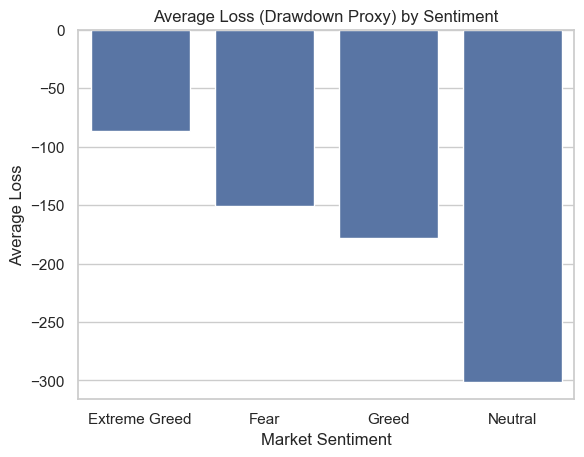

In [32]:
sns.barplot(data=drawdown_proxy, x='classification', y='Closed PnL')
plt.title("Average Loss (Drawdown Proxy) by Sentiment")
plt.ylabel("Average Loss")
plt.xlabel("Market Sentiment")
plt.show()

Behavioral Changes Based on Sentiment

In [33]:
# Trade Frequency
trades_sentiment = merged_data.groupby('classification').size().reset_index(name='trade_count')
trades_sentiment

,classification,trade_count
0,Extreme Greed,6962
1,Fear,133871
2,Greed,36289
3,Neutral,7141


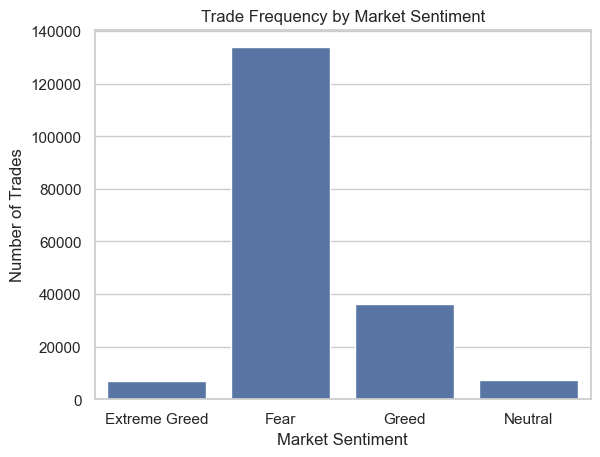

In [34]:
sns.barplot(data=trades_sentiment, x='classification', y='trade_count')
plt.title("Trade Frequency by Market Sentiment")
plt.ylabel("Number of Trades")
plt.xlabel("Market Sentiment")
plt.show()

In [35]:
# Position Size Comparison
size_sentiment = merged_data.groupby('classification')['Size USD'].mean().reset_index()
size_sentiment

,classification,Size USD
0,Extreme Greed,5660.265764
1,Fear,5259.977837
2,Greed,3182.883845
3,Neutral,3058.848110


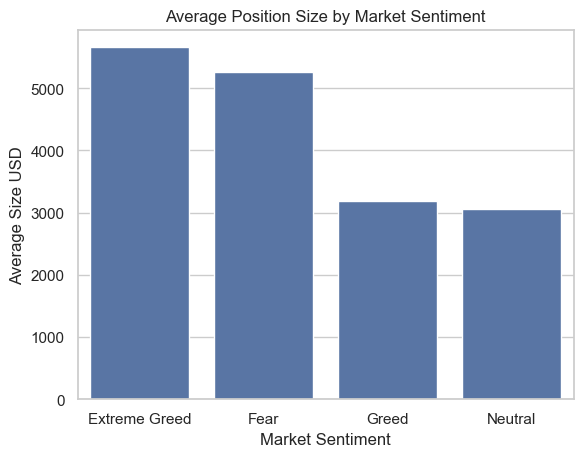

In [36]:
sns.barplot(data=size_sentiment, x='classification', y='Size USD')
plt.title("Average Position Size by Market Sentiment")
plt.ylabel("Average Size USD")
plt.xlabel("Market Sentiment")
plt.show()

In [37]:
# Long vs Short Bias
long_short_sentiment = merged_data.groupby(['classification','Side']).size().reset_index(name='count')

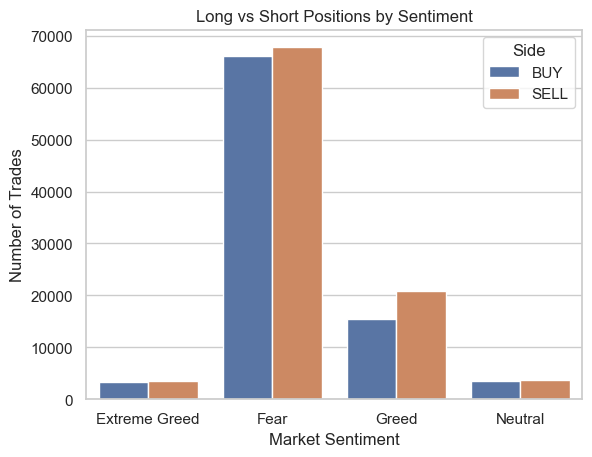

In [38]:
sns.barplot(data=long_short_sentiment, x='classification', y='count', hue='Side')
plt.title("Long vs Short Positions by Sentiment")
plt.ylabel("Number of Trades")
plt.xlabel("Market Sentiment")
plt.show()

Trader Segmentation

In [39]:
# Frequent vs Infrequent Traders
trader_activity = merged_data.groupby('Account').size().reset_index(name='trade_count')
trader_activity['activity_segment'] = pd.qcut(
    trader_activity['trade_count'],
    q=2,
    labels=['Infrequent','Frequent']
)

In [40]:
trader_activity.head()

,Account,trade_count,activity_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent


In [41]:
merged_data = merged_data.merge(trader_activity[['Account','activity_segment']], on='Account')

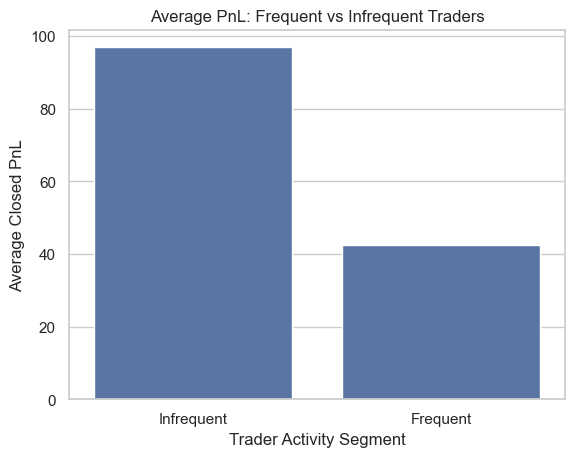

In [42]:
# Average PnL by Activity Segment
activity_pnl = merged_data.groupby('activity_segment')['Closed PnL'].mean().reset_index()

sns.barplot(data=activity_pnl, x='activity_segment', y='Closed PnL')
plt.title("Average PnL: Frequent vs Infrequent Traders")
plt.xlabel("Trader Activity Segment")
plt.ylabel("Average Closed PnL")
plt.show()

In [43]:
# High vs Low Exposure Traders
merged_data['exposure_segment'] = pd.qcut(
    merged_data['Size USD'],
    q=2,
    labels=['Low Exposure','High Exposure']
)

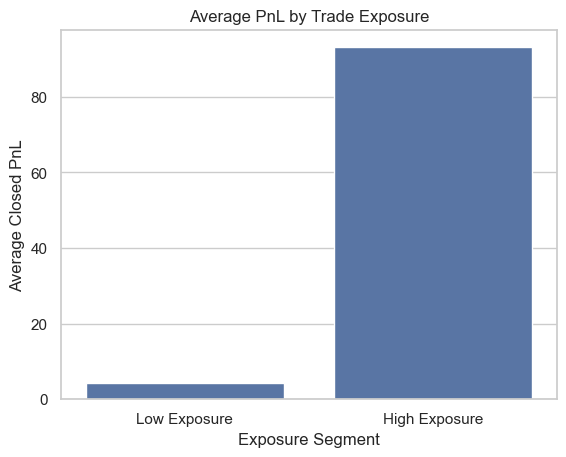

In [44]:
exposure_pnl = merged_data.groupby('exposure_segment')['Closed PnL'].mean().reset_index()

sns.barplot(data=exposure_pnl, x='exposure_segment', y='Closed PnL')
plt.title("Average PnL by Trade Exposure")
plt.xlabel("Exposure Segment")
plt.ylabel("Average Closed PnL")
plt.show()

In [45]:
# Consistent vs Inconsistent Winners
# win rate per trader.
trader_winrate = merged_data.groupby('Account')['win'].mean().reset_index()
trader_winrate['performance_segment'] = pd.cut(
    trader_winrate['win'],
    bins=[0,0.5,1],
    labels=['Inconsistent','Consistent']
)

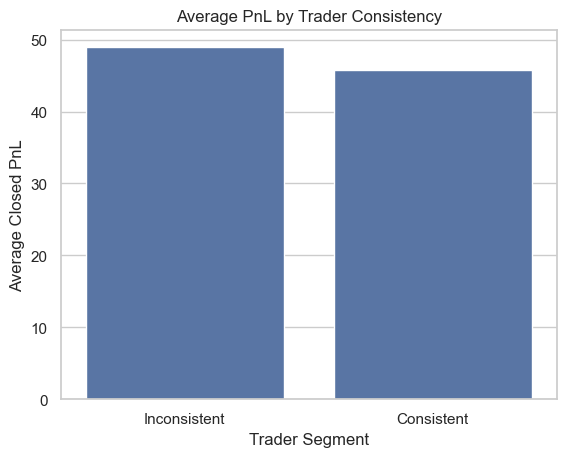

In [46]:
merged_data = merged_data.merge(trader_winrate[['Account','performance_segment']], on='Account')
performance_pnl = merged_data.groupby('performance_segment')['Closed PnL'].mean().reset_index()

sns.barplot(data=performance_pnl, x='performance_segment', y='Closed PnL')
plt.title("Average PnL by Trader Consistency")
plt.xlabel("Trader Segment")
plt.ylabel("Average Closed PnL")
plt.show()

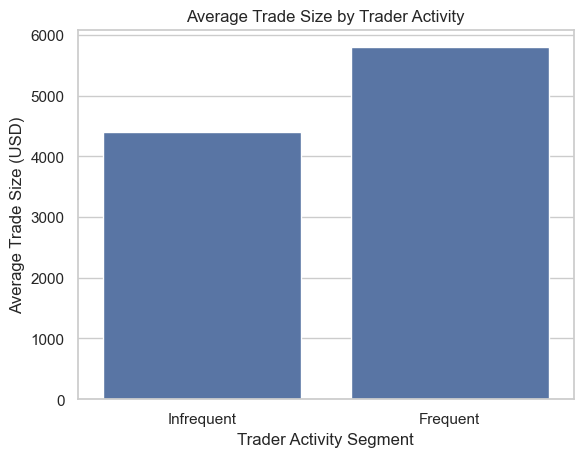

In [47]:
size_segment = merged_data.groupby('activity_segment')['Size USD'].mean().reset_index()

sns.barplot(data=size_segment, x='activity_segment', y='Size USD')
plt.title("Average Trade Size by Trader Activity")
plt.xlabel("Trader Activity Segment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

### Average PnL by Market Sentiment

This chart compares the average profit and loss (PnL) of trades executed during Fear and Greed market conditions.

PnL measures the profitability of trades. A higher average PnL indicates better trading performance.

This visualization helps determine whether trader profitability differs depending on overall market sentiment.

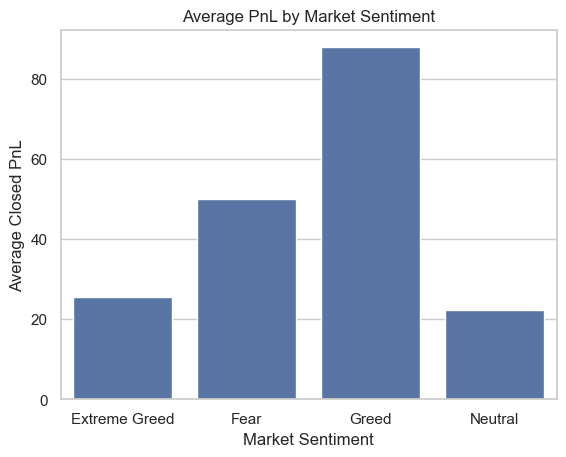

In [48]:
pnl_by_sentiment = merged_data.groupby('classification')['Closed PnL'].mean().reset_index()

sns.barplot(data=pnl_by_sentiment, x='classification', y='Closed PnL')
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

### Win Rate by Market Sentiment

Win rate represents the proportion of profitable trades relative to total trades.

This chart compares trader success rates during Fear and Greed market conditions.

It helps determine whether traders are more successful in optimistic markets (Greed) or cautious markets (Fear).

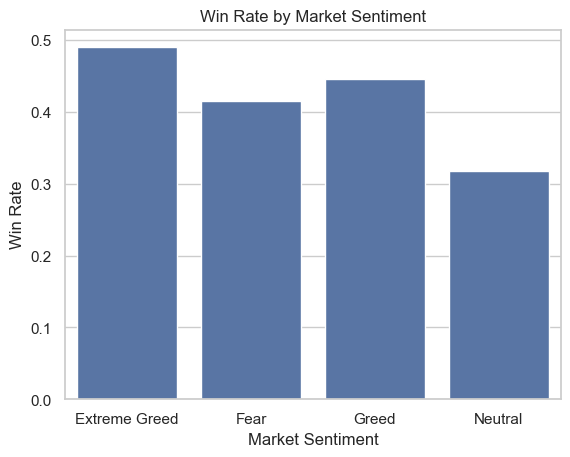

In [49]:
merged_data['win'] = merged_data['Closed PnL'] > 0

win_rate_sentiment = merged_data.groupby('classification')['win'].mean().reset_index()

sns.barplot(data=win_rate_sentiment, x='classification', y='win')
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.show()

### Trade Frequency by Market Sentiment

Trade frequency represents the number of trades executed during different market sentiment conditions.

This chart shows whether traders are more active during Fear or Greed periods.

Higher trade frequency may indicate increased market participation or speculative behavior.

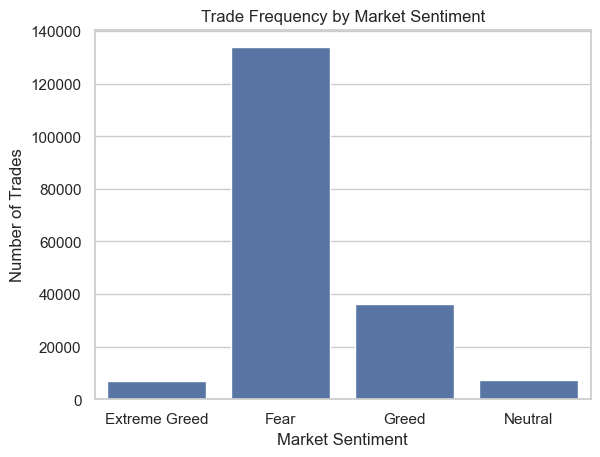

In [50]:
trades_sentiment = merged_data.groupby('classification').size().reset_index(name='trade_count')

sns.barplot(data=trades_sentiment, x='classification', y='trade_count')
plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

### Average Position Size by Market Sentiment

Position size represents the dollar value of each trade.

This chart compares average trade size during Fear and Greed periods.

Larger position sizes may indicate higher confidence or greater risk-taking behavior by traders.

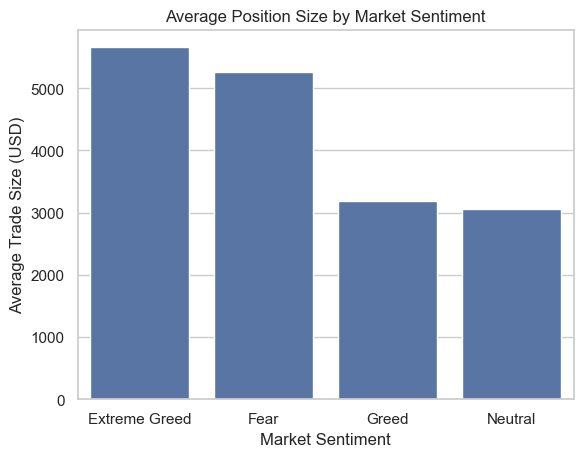

In [51]:
size_sentiment = merged_data.groupby('classification')['Size USD'].mean().reset_index()

sns.barplot(data=size_sentiment, x='classification', y='Size USD')
plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

### Insights

Summary of Insights from the Charts

1. Most Trades Occur During Fear

The Fear market sentiment has by far the highest number of trades.
Traders are most active when the market is fearful, likely due to increased volatility and opportunities.

2. Greed Produces the Highest Profit per Trade

Greed sentiment shows the highest average closed PnL.
This suggests trades opened during bullish momentum tend to generate larger profits.

3. Best Win Rate Happens in Extreme Greed

Extreme Greed has the highest win rate (~49%).
However, despite winning more often, the profits per trade are smaller compared to Greed.

4. Largest Position Sizes in Extreme Greed and Fear

Traders take larger positions during Extreme Greed and Fear.
This indicates higher confidence or stronger reactions during emotionally intense market conditions.

5. Neutral Markets Perform the Worst

Neutral sentiment has:
The lowest win rate (~32%)
The lowest average PnL
This suggests sideways markets are harder to trade profitably.

#### Overall Takeaway

Fear = Most trading activity

Greed = Highest profitability

Extreme Greed = Best win rate but smaller gains per trade

Neutral = Weak trading performance

In simple terms:
Traders trade the most during fear, but they make the most money during greed-driven markets.

## Part C — Actionable Output (Strategy Ideas / Rules of Thumb)

### Strategy 1: Increase Trading During Greed, Reduce During Neutral

Rule of Thumb : 

1. When Market Sentiment = Greed

Increase trade frequency.

Allow slightly larger position sizes.

Focus on momentum-following strategies.

2. When Market Sentiment = Neutral

Reduce trading activity.

Avoid aggressive entries.

Only take high-confidence setups.

#### Reasoning

Greed shows the highest average profit per trade, meaning trends are strong and profitable opportunities are clearer.

Neutral markets show the lowest win rate and lowest PnL, indicating choppy or sideways conditions where strategies perform poorly.

#### Expected Outcome

Higher capital efficiency.

Reduced losses from low-probability trades.

### Strategy 2: Risk-Control Strategy During Fear and Extreme Greed

Rule of Thumb

1. During Fear

Trade frequently but use smaller position sizes.

Focus on short-term trades (scalping or quick reversals).

Use tighter stop losses.

2. During Extreme Greed

Maintain larger positions but lock profits faster.

Implement partial take-profit levels.

#### Reasoning

Fear has the highest trading activity, indicating volatile markets with many opportunities but also higher risk.

Extreme Greed has the highest win rate, but profits per trade are lower, suggesting frequent small winning trades rather than large moves.

#### Expected Outcome

Better risk management during volatile conditions.

Improved consistency in win rates and overall portfolio stability.